In [ ]:
# ── Standard Data Science Libraries ──────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.graph_objects as go

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from yellowbrick.cluster import SilhouetteVisualizer

# ── Plot Style ────────────────────────────────────────────────────────────────
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42

print("All libraries imported successfully.")

All libraries imported successfully.


In [ ]:
# ── Load raw dataset ──────────────────────────────────────────────────────────
# The file 'flight.csv' should be placed in a 'data/' subdirectory.
# This dataset is sourced from Kaggle (SA Customer Segmentation).
df_raw = pd.read_csv('/content/flight.csv')

print(f"Dataset shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print("\n── First 5 rows ─────────────────────────────────────────────────────────")
df_raw.head()

Dataset shape: 62,988 rows × 23 columns

── First 5 rows ─────────────────────────────────────────────────────────


,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME,...,SUM_YR_2,SEG_KM_SUM,LAST_FLIGHT_DATE,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
0,54993,11/2/2006,12/24/2008,Male,6,.,beijing,CN,31.0,3/31/2014,...,234188.0,580717,3/31/2014,1,3.483254,18,34,0.961639,619760,50
1,28065,2/19/2007,8/3/2007,Male,6,NaN,beijing,CN,42.0,3/31/2014,...,167434.0,293678,3/25/2014,7,5.194245,17,29,1.252314,415768,33
2,55106,2/1/2007,8/30/2007,Male,6,.,beijing,CN,40.0,3/31/2014,...,164982.0,283712,3/21/2014,11,5.298507,18,20,1.254676,406361,26
3,21189,8/22/2008,8/23/2008,Male,5,Los Angeles,CA,US,64.0,3/31/2014,...,125500.0,281336,12/26/2013,97,27.863636,73,11,1.090870,372204,12
4,39546,4/10/2009,4/15/2009,Male,6,guiyang,guizhou,CN,48.0,3/31/2014,...,130702.0,309928,3/27/2014,5,4.788079,47,27,0.970658,338813,39


In [ ]:
# ── Data types and non-null counts ────────────────────────────────────────────
# This tells us which columns have missing values and what type each column is.
# Object columns = strings/dates that may need parsing.
# Float columns with missing counts = need handling.
print("── Data Info ─────────────────────────────────────────────────────────────")
df_raw.info()

── Data Info ─────────────────────────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62988 entries, 0 to 62987
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MEMBER_NO          62988 non-null  int64  
 1   FFP_DATE           62988 non-null  object 
 2   FIRST_FLIGHT_DATE  62988 non-null  object 
 3   GENDER             62985 non-null  object 
 4   FFP_TIER           62988 non-null  int64  
 5   WORK_CITY          60719 non-null  object 
 6   WORK_PROVINCE      59740 non-null  object 
 7   WORK_COUNTRY       62962 non-null  object 
 8   AGE                62568 non-null  float64
 9   LOAD_TIME          62988 non-null  object 
 10  FLIGHT_COUNT       62988 non-null  int64  
 11  BP_SUM             62988 non-null  int64  
 12  SUM_YR_1           62437 non-null  float64
 13  SUM_YR_2           62850 non-null  float64
 14  SEG_KM_SUM         62988 non-null  int64  


In [ ]:
# ── Missing value summary ─────────────────────────────────────────────────────
# We calculate both the count and percentage of missing values per column.
# This helps us decide which columns to drop vs. impute.
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(3)

missing_df = pd.DataFrame({
    'columns': df_raw.columns,
    'missing_values': missing.values,
    'pct': missing_pct.values
})
missing_df = missing_df[missing_df['missing_values'] > 0].reset_index(drop=True)
print("Columns with missing values:")
print(missing_df.to_string(index=False))
print(f"\nTotal records affected: {df_raw.isnull().any(axis=1).sum():,}")
print(f"Percentage of total rows: {df_raw.isnull().any(axis=1).mean()*100:.2f}%")

Columns with missing values:
      columns  missing_values   pct
       GENDER               3 0.005
    WORK_CITY            2269 3.602
WORK_PROVINCE            3248 5.157
 WORK_COUNTRY              26 0.041
          AGE             420 0.667
     SUM_YR_1             551 0.875
     SUM_YR_2             138 0.219

Total records affected: 4,733
Percentage of total rows: 7.51%


In [ ]:
# ── Check for duplicate rows ──────────────────────────────────────────────────
# Duplicate rows would inflate certain traveller profiles unfairly in clustering.
n_dupes = df_raw.duplicated().sum()
print(f"Number of fully duplicated rows: {n_dupes}")

Number of fully duplicated rows: 0


In [ ]:
# ── Step 1: Drop rows with any missing values ─────────────────────────────────
# We work on a copy to preserve the raw data for reference.
df = df_raw.copy()
before = len(df)
df.dropna(inplace=True)
after = len(df)
print(f"Records before dropping NaN : {before:,}")
print(f"Records after dropping NaN  : {after:,}")
print(f"Records removed             : {before - after:,} ({(before-after)/before*100:.2f}%)")

Records before dropping NaN : 62,988
Records after dropping NaN  : 58,255
Records removed             : 4,733 (7.51%)


In [ ]:
# ── Step 2: Domain-specific anomaly removal ───────────────────────────────────
#
# Condition A: Either booking revenue column (SUM_YR_1 or SUM_YR_2) is zero
#   → Traveller has no meaningful booking revenue; exclude.
#
# Condition B: Booking value = 0 AND avg_discount != 0 AND distance > 0
#   → Contradictory record (trip taken for free with a discount applied).
#
# We KEEP records that do NOT match these anomaly conditions.

condition_A = (df['SUM_YR_1'] == 0) | (df['SUM_YR_2'] == 0)
condition_B = (
    ((df['SUM_YR_1'] == 0) | (df['SUM_YR_2'] == 0)) &
    (df['avg_discount'] != 0) &
    (df['SEG_KM_SUM'] > 0)
)

before = len(df)
df = df[~condition_A | ~condition_B]
# Refined: keep only records where both revenue columns are non-zero
df = df[(df['SUM_YR_1'] > 0) & (df['SUM_YR_2'] > 0)]
after = len(df)

print(f"Records before anomaly removal : {before:,}")
print(f"Records after anomaly removal  : {after:,}")
print(f"Records removed                : {before - after:,}")
print(f"\n✅ Clean dataset ready: {after:,} traveller records.")

Records before anomaly removal : 58,255
Records after anomaly removal  : 38,966
Records removed                : 19,289

✅ Clean dataset ready: 38,966 traveller records.


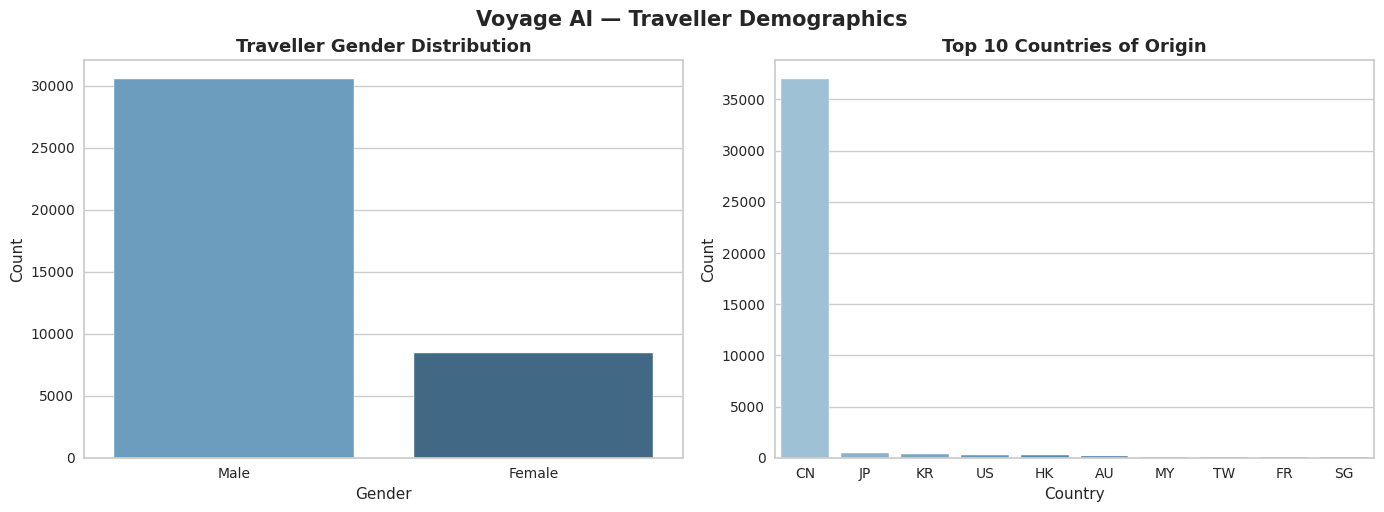

Most common gender      : Male (30,525 travellers)
Most common country     : CN (36,974 travellers)


In [ ]:
# ── EDA: Categorical columns ──────────────────────────────────────────────────
# We look at GENDER and WORK_COUNTRY to understand who our travellers are.
# Top-10 cities and provinces are also shown to understand geographic distribution.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender
gender_counts = df['GENDER'].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values, ax=axes[0], palette='Blues_d')
axes[0].set_title('Traveller Gender Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')

# Top 10 countries
top_countries = df['WORK_COUNTRY'].value_counts().head(10)
sns.barplot(x=top_countries.index, y=top_countries.values, ax=axes[1], palette='Blues_d')
axes[1].set_title('Top 10 Countries of Origin', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.suptitle('Voyage AI — Traveller Demographics', fontsize=15, fontweight='bold', y=1.02)
plt.show()

print(f"Most common gender      : {gender_counts.index[0]} ({gender_counts.values[0]:,} travellers)")
print(f"Most common country     : {top_countries.index[0]} ({top_countries.values[0]:,} travellers)")

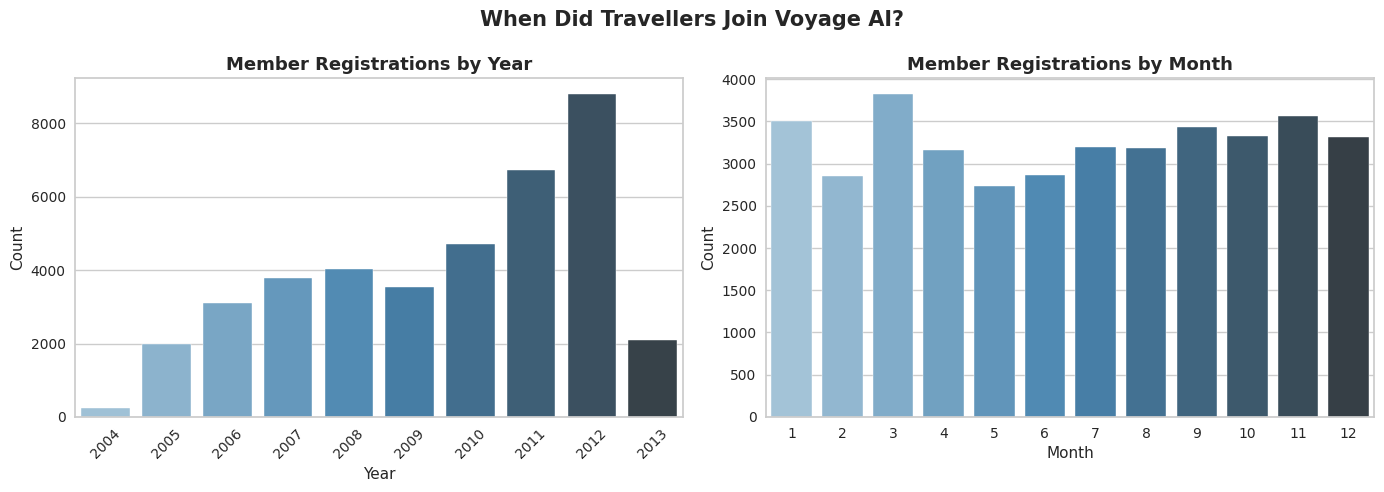

In [ ]:
# ── EDA: Membership join date ─────────────────────────────────────────────────
# FFP_DATE tells us when a traveller first registered with the platform.
# Parsing it reveals when user growth happened and informs our 'loyalty_tenure' feature.

df['FFP_DATE_parsed'] = pd.to_datetime(df['FFP_DATE'], format='%m/%d/%Y')
df['LOAD_TIME_parsed'] = pd.to_datetime(df['LOAD_TIME'], format='%m/%d/%Y')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By year
year_counts = df['FFP_DATE_parsed'].dt.year.value_counts().sort_index()
sns.barplot(x=year_counts.index, y=year_counts.values, ax=axes[0], palette='Blues_d')
axes[0].set_title('Member Registrations by Year', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# By month
month_counts = df['FFP_DATE_parsed'].dt.month.value_counts().sort_index()
sns.barplot(x=month_counts.index, y=month_counts.values, ax=axes[1], palette='Blues_d')
axes[1].set_title('Member Registrations by Month', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Count')

plt.suptitle('When Did Travellers Join Voyage AI?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

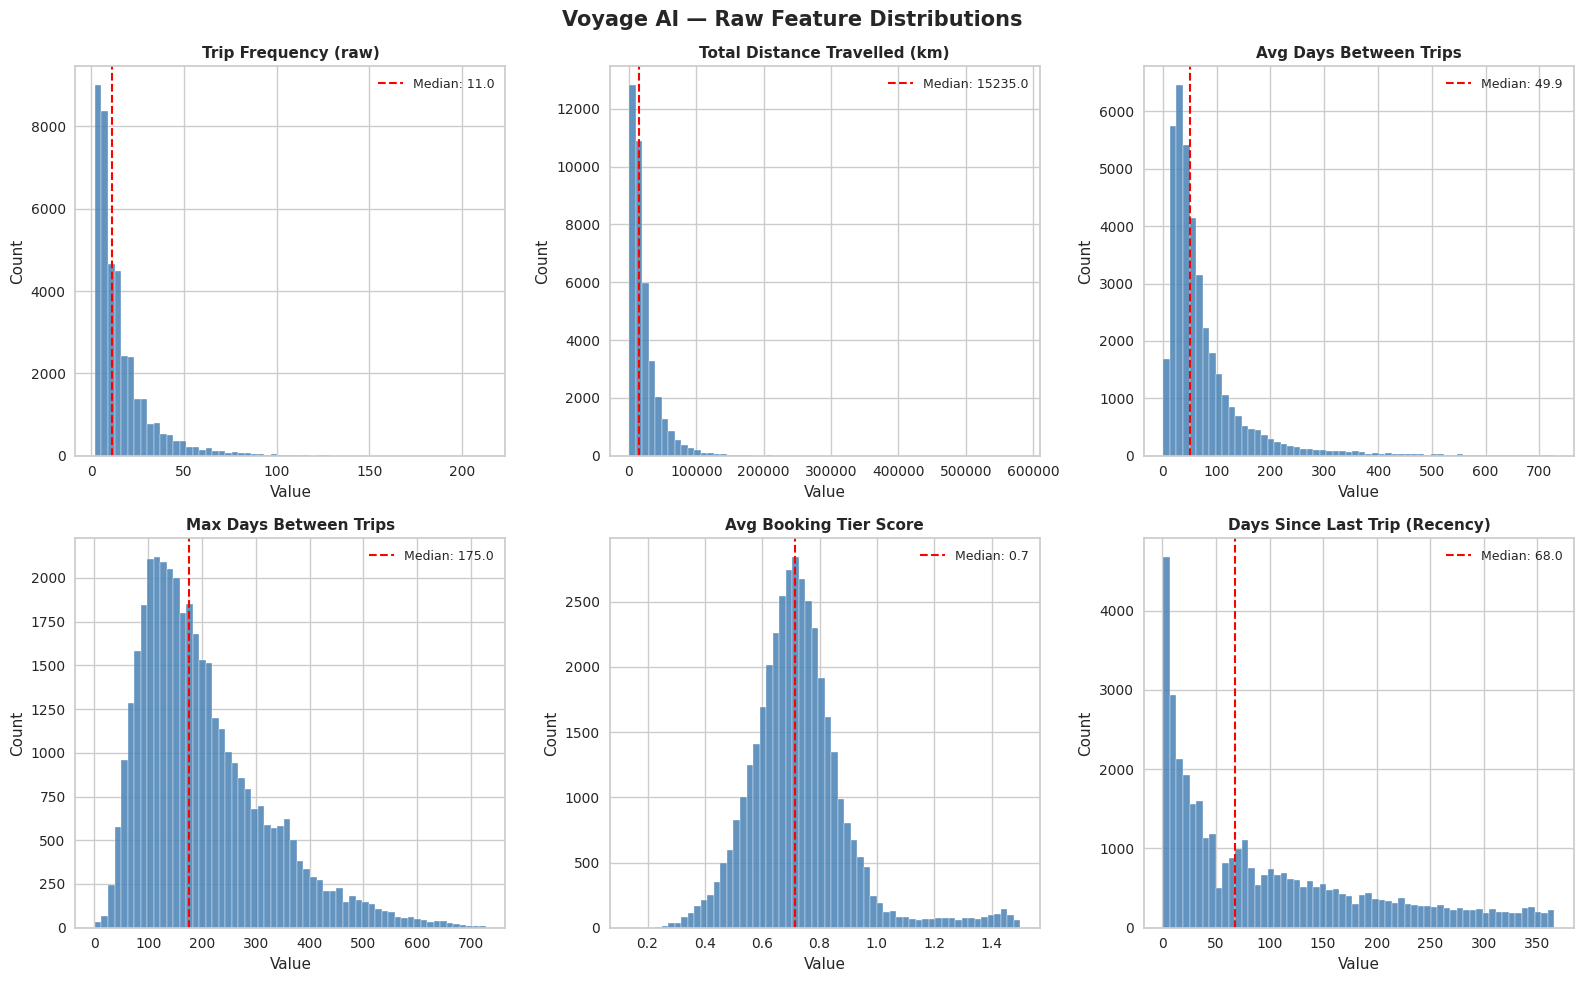

In [ ]:
# ── EDA: Key numerical columns that feed into our features ────────────────────
# We look at the raw distributions before any transformation.
# Note: FLIGHT_COUNT and SEG_KM_SUM are heavily right-skewed (many low-frequency
# travellers, a few very frequent ones) — this is typical of travel data.

num_cols = {
    'FLIGHT_COUNT'  : 'Trip Frequency (raw)',
    'SEG_KM_SUM'    : 'Total Distance Travelled (km)',
    'AVG_INTERVAL'  : 'Avg Days Between Trips',
    'MAX_INTERVAL'  : 'Max Days Between Trips',
    'avg_discount'  : 'Avg Booking Tier Score',
    'LAST_TO_END'   : 'Days Since Last Trip (Recency)'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (col, title) in enumerate(num_cols.items()):
    data = df[col]
    axes[i].hist(data, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(title, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].axvline(data.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median: {data.median():.1f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Voyage AI — Raw Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Feature Engineering ───────────────────────────────────────────────────────
# We compute each Voyage AI feature from the raw columns.

df_features = df.copy()

# ── Feature 1: trip_frequency ─────────────────────────────────────────────────
# Direct mapping from FLIGHT_COUNT.
# This represents how many trips a traveller has taken in the observation window.
df_features['trip_frequency'] = df_features['FLIGHT_COUNT']

# ── Feature 2: avg_booking_value ──────────────────────────────────────────────
# Average revenue per trip across both fare revenue streams.
# SUM_YR_1 = primary fare, SUM_YR_2 = ancillary/voted prices.
# Dividing by FLIGHT_COUNT normalises to a per-trip value.
df_features['avg_booking_value'] = (
    (df_features['SUM_YR_1'] + df_features['SUM_YR_2']) / df_features['FLIGHT_COUNT']
)

# ── Feature 3: destination_diversity ─────────────────────────────────────────
# Captures how varied a traveller's booking patterns are.
# MAX_INTERVAL - AVG_INTERVAL: large gap means some trips are clustered close
# together and others are far apart → diverse, multi-destination travel style.
# We clip at 0 to avoid negatives from floating-point edge cases.
df_features['destination_diversity'] = (
    df_features['MAX_INTERVAL'] - df_features['AVG_INTERVAL']
).clip(lower=0)

# ── Feature 4: session_engagement ────────────────────────────────────────────
# Proxy for platform engagement between booking sessions.
# We use AVG_INTERVAL (average days between trips).
# A lower average interval = traveller returns to the platform more frequently.
# Note: this is kept as-is (not inverted) — lower = more engaged traveller.
df_features['session_engagement'] = df_features['AVG_INTERVAL']

# ── Feature 5: search_recency ─────────────────────────────────────────────────
# Days since the traveller's last recorded trip/booking to the observation window end.
# Lower = more recently active = higher recency score.
# This is equivalent to 'R' (Recency) in the RFM model.
df_features['search_recency'] = df_features['LAST_TO_END']

# ── Feature 6: loyalty_tenure ─────────────────────────────────────────────────
# How long (in months) the traveller has been a registered member.
# Computed as: (observation end date - membership join date) in days, then /30.
df_features['loyalty_tenure'] = (
    (df_features['LOAD_TIME_parsed'] - df_features['FFP_DATE_parsed']).dt.days / 30
).round(2)

# ── Collect only our 6 engineered features ────────────────────────────────────
feature_cols = [
    'trip_frequency',
    'avg_booking_value',
    'destination_diversity',
    'session_engagement',
    'search_recency',
    'loyalty_tenure'
]

df_voyage = df_features[feature_cols].copy()
df_voyage.reset_index(drop=True, inplace=True)

print("✅ Voyage AI feature set engineered successfully.")
print(f"Shape: {df_voyage.shape[0]:,} travellers × {df_voyage.shape[1]} features\n")
df_voyage.head(10)

✅ Voyage AI feature set engineered successfully.
Shape: 38,966 travellers × 6 features



,trip_frequency,avg_booking_value,destination_diversity,session_engagement,search_recency,loyalty_tenure
0,210,2255.942857,14.516746,3.483254,1,90.20
1,135,2434.074074,12.701493,5.298507,11,87.17
2,23,10515.217391,45.136364,27.863636,97,68.23
3,152,1679.355263,42.211921,4.788079,5,60.53
4,92,2057.717391,44.956044,7.043956,79,74.70
5,101,2326.425743,20.810000,7.190000,1,97.70
6,73,2704.260274,34.888889,10.111111,3,48.40
7,64,2273.828125,61.666667,11.333333,15,45.50
8,43,3735.744186,78.166667,16.833333,22,40.97
9,145,1515.834483,36.972222,5.027778,6,114.17


In [ ]:
# ── Descriptive statistics of all 6 engineered features ──────────────────────
# This gives us a sense of scale, skewness, and range before scaling.
print("── Descriptive Statistics of Voyage AI Features ─────────────────────────")
df_voyage.describe().round(2)

── Descriptive Statistics of Voyage AI Features ─────────────────────────


,trip_frequency,avg_booking_value,destination_diversity,session_engagement,search_recency,loyalty_tenure
count,38966.00,38966.00,38966.00,38966.00,38966.00,38966.00
mean,15.85,946.12,127.57,75.10,100.54,50.60
std,15.86,558.41,82.27,80.50,97.51,28.40
min,2.00,58.52,0.00,1.00,1.00,12.17
25%,6.00,669.21,70.38,29.42,19.00,25.33
50%,11.00,839.67,110.51,49.92,68.00,43.73
75%,20.00,1071.16,168.85,88.43,158.00,73.97
max,213.00,21401.24,547.31,728.00,366.00,114.57


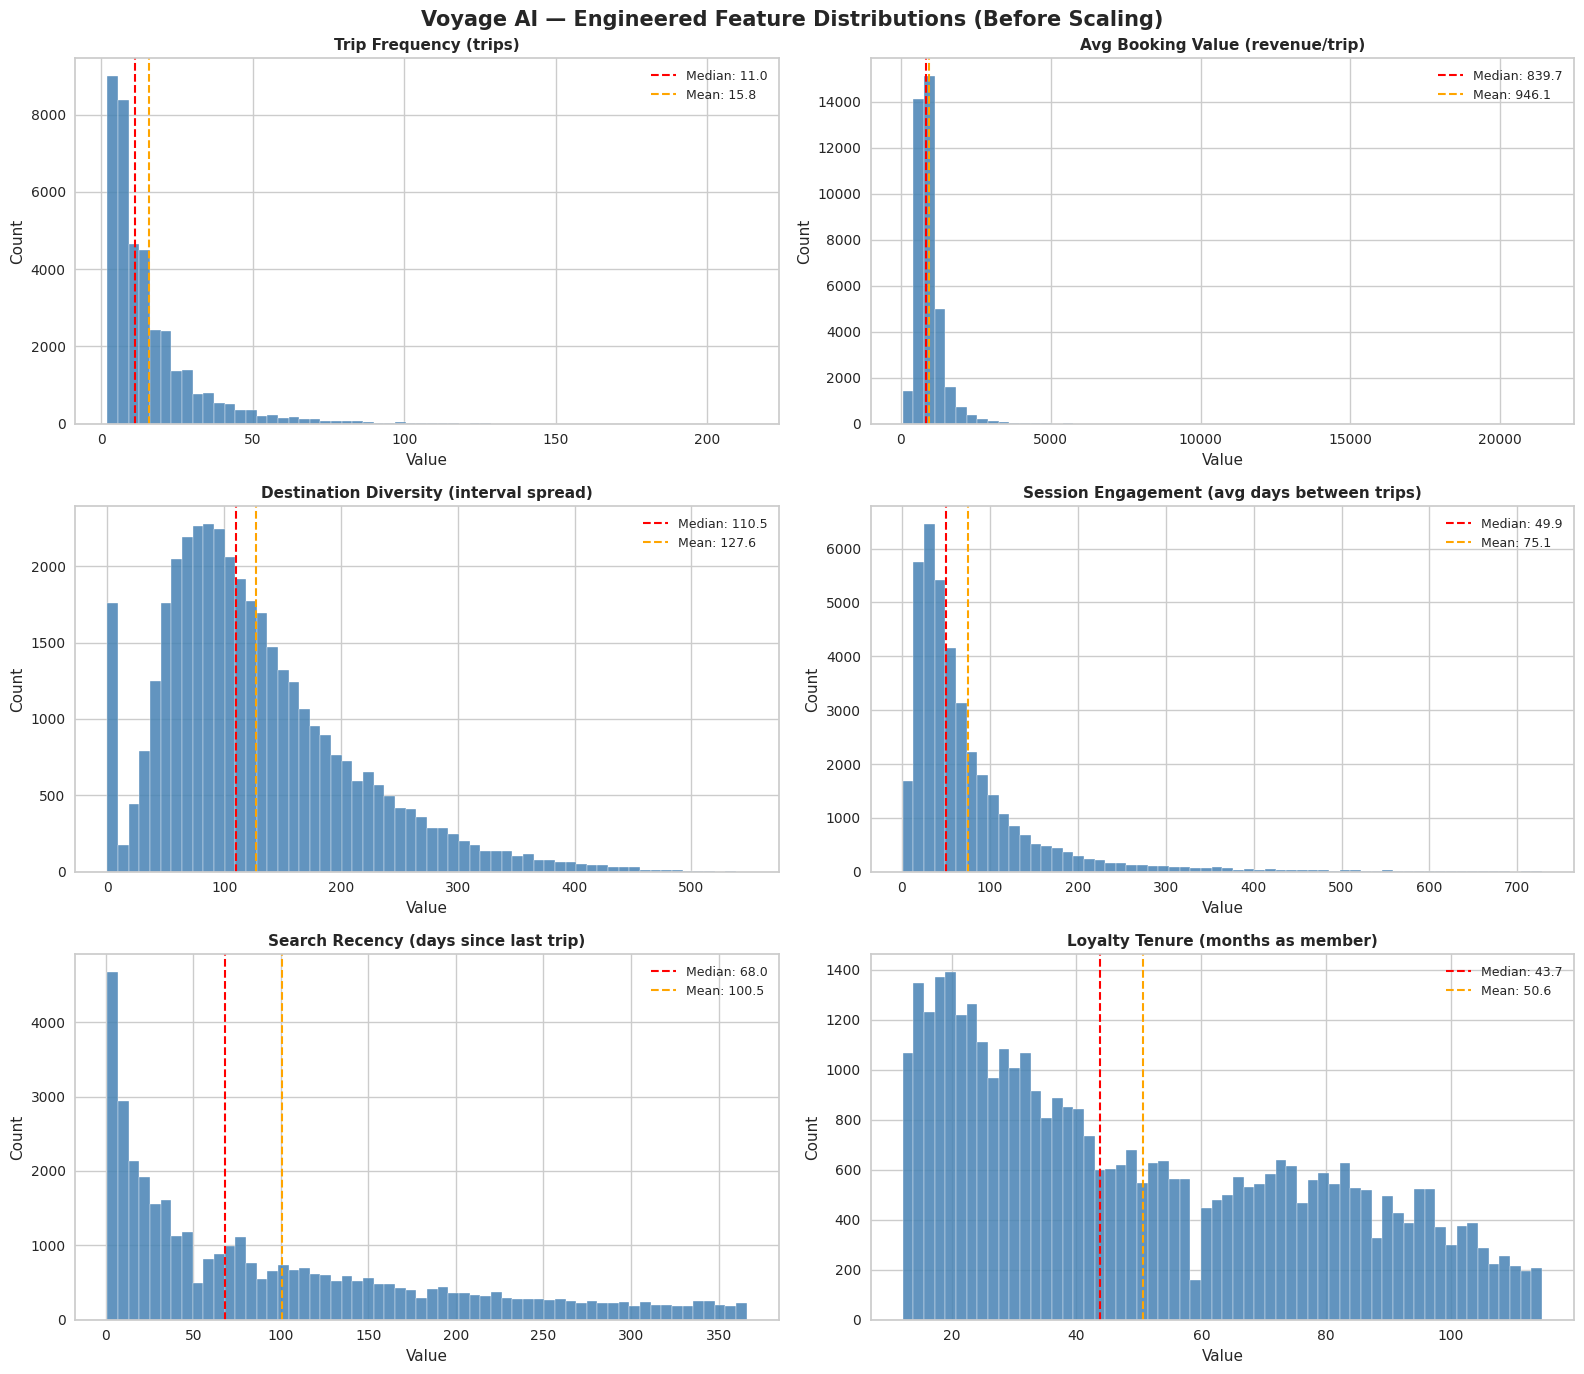

In [ ]:
# ── Visualise all 6 engineered features ──────────────────────────────────────
# We plot histogram + boxplot for each feature to check skewness.
# Skewed features (trip_frequency, avg_booking_value) will need log transformation
# before feeding into K-Means (which uses Euclidean distance).

feature_labels = {
    'trip_frequency'        : 'Trip Frequency (trips)',
    'avg_booking_value'     : 'Avg Booking Value (revenue/trip)',
    'destination_diversity' : 'Destination Diversity (interval spread)',
    'session_engagement'    : 'Session Engagement (avg days between trips)',
    'search_recency'        : 'Search Recency (days since last trip)',
    'loyalty_tenure'        : 'Loyalty Tenure (months as member)'
}

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, (col, label) in enumerate(feature_labels.items()):
    data = df_voyage[col]
    ax = axes[i]
    ax.hist(data, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():.1f}')
    ax.axvline(data.mean(), color='orange', linestyle='--', linewidth=1.5,
               label=f'Mean: {data.mean():.1f}')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('Voyage AI — Engineered Feature Distributions (Before Scaling)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

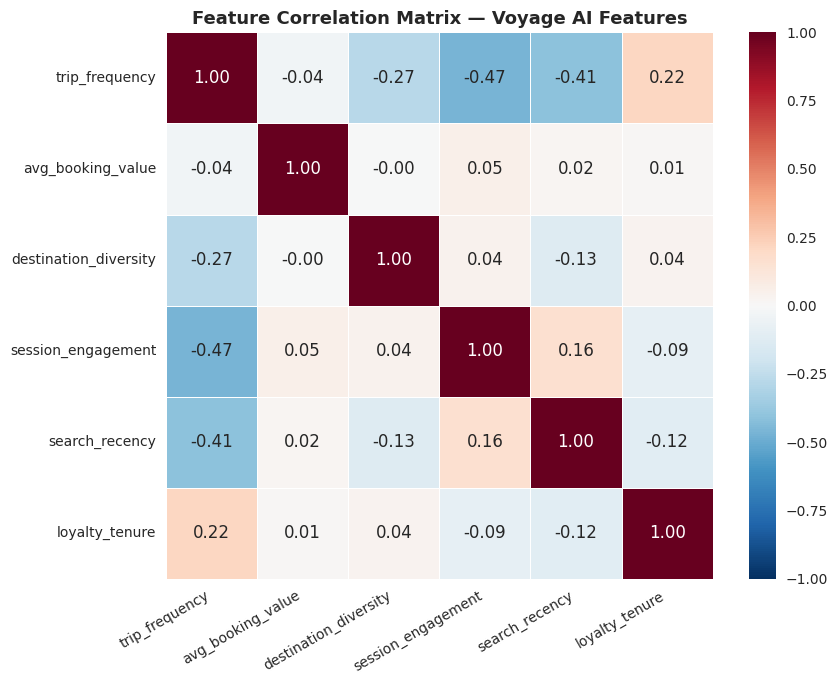

Key correlations:
  trip_frequency ↔ avg_booking_value      : -0.035
  trip_frequency ↔ search_recency         : -0.409
  loyalty_tenure ↔ trip_frequency         : 0.217


In [ ]:
# ── Correlation heatmap of engineered features ────────────────────────────────
# Understanding feature correlations before clustering:
# - High correlation between trip_frequency and avg_booking_value is expected
#   (frequent travellers tend to accumulate more value).
# - search_recency should negatively correlate with trip_frequency
#   (recently active travellers tend to fly more often).

corr_matrix = df_voyage.corr()

plt.figure(figsize=(9, 7))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Feature Correlation Matrix — Voyage AI Features',
          fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print("Key correlations:")
print(f"  trip_frequency ↔ avg_booking_value      : {corr_matrix.loc['trip_frequency','avg_booking_value']:.3f}")
print(f"  trip_frequency ↔ search_recency         : {corr_matrix.loc['trip_frequency','search_recency']:.3f}")
print(f"  loyalty_tenure ↔ trip_frequency         : {corr_matrix.loc['loyalty_tenure','trip_frequency']:.3f}")

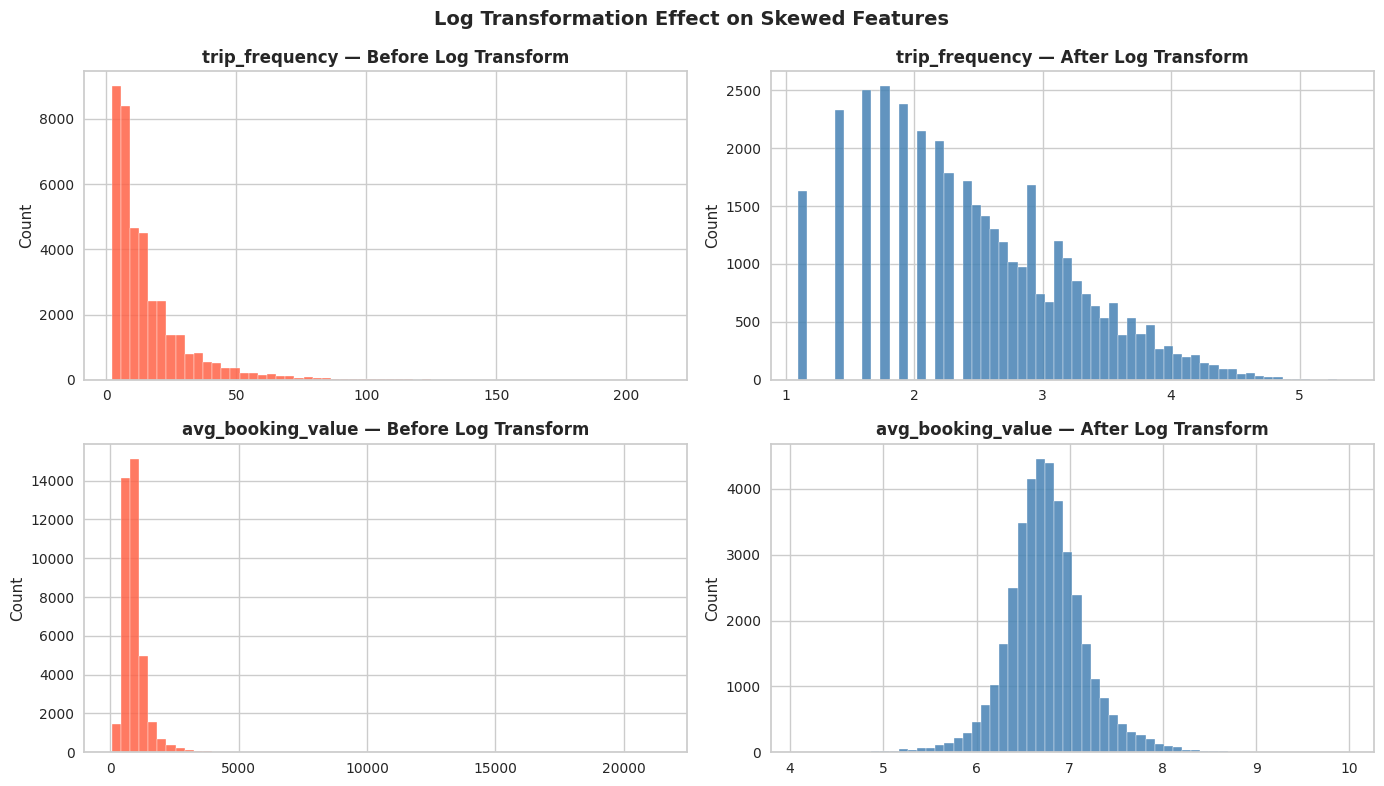

✅ Log transformation applied to: trip_frequency, avg_booking_value


In [ ]:
# ── Log Transformation ────────────────────────────────────────────────────────
# We apply log1p (log(1+x)) instead of log to safely handle any zero values.
# This compresses the right tail and makes the distributions more symmetric.

df_voyage_log = df_voyage.copy()
log_cols = ['trip_frequency', 'avg_booking_value']

for col in log_cols:
    df_voyage_log[col] = np.log1p(df_voyage_log[col])

# ── Plot before vs after for the two log-transformed features ─────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, col in enumerate(log_cols):
    # Before
    axes[i][0].hist(df_voyage[col], bins=60, color='tomato', edgecolor='white', alpha=0.85)
    axes[i][0].set_title(f'{col} — Before Log Transform', fontweight='bold')
    axes[i][0].set_ylabel('Count')

    # After
    axes[i][1].hist(df_voyage_log[col], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i][1].set_title(f'{col} — After Log Transform', fontweight='bold')
    axes[i][1].set_ylabel('Count')

plt.suptitle('Log Transformation Effect on Skewed Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Log transformation applied to: trip_frequency, avg_booking_value")

In [ ]:
# ── Standard Scaling ──────────────────────────────────────────────────────────
# StandardScaler transforms each feature to have mean=0 and std=1.
# This ensures no single feature dominates the Euclidean distance metric in K-Means.

scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_voyage_log)

# Store in a labelled DataFrame for interpretability
df_scaled = pd.DataFrame(scaled_values, columns=feature_cols)

print("── Scaled Feature Statistics (should be ~0 mean, ~1 std) ────────────────")
stats = df_scaled.describe().loc[['mean', 'std']].round(4)
print(stats.to_string())
print("\n✅ StandardScaler applied. All features now at comparable scale.")

── Scaled Feature Statistics (should be ~0 mean, ~1 std) ────────────────
      trip_frequency  avg_booking_value  destination_diversity  session_engagement  search_recency  loyalty_tenure
mean             0.0                0.0                   -0.0                 0.0             0.0             0.0
std              1.0                1.0                    1.0                 1.0             1.0             1.0

✅ StandardScaler applied. All features now at comparable scale.


Fitting K-Means for k = 2 to 10...
  k=2  |  Inertia: 182,128
  k=3  |  Inertia: 156,182
  k=4  |  Inertia: 135,701
  k=5  |  Inertia: 118,678
  k=6  |  Inertia: 109,429
  k=7  |  Inertia: 102,004
  k=8  |  Inertia: 96,033
  k=9  |  Inertia: 91,573
  k=10  |  Inertia: 87,263


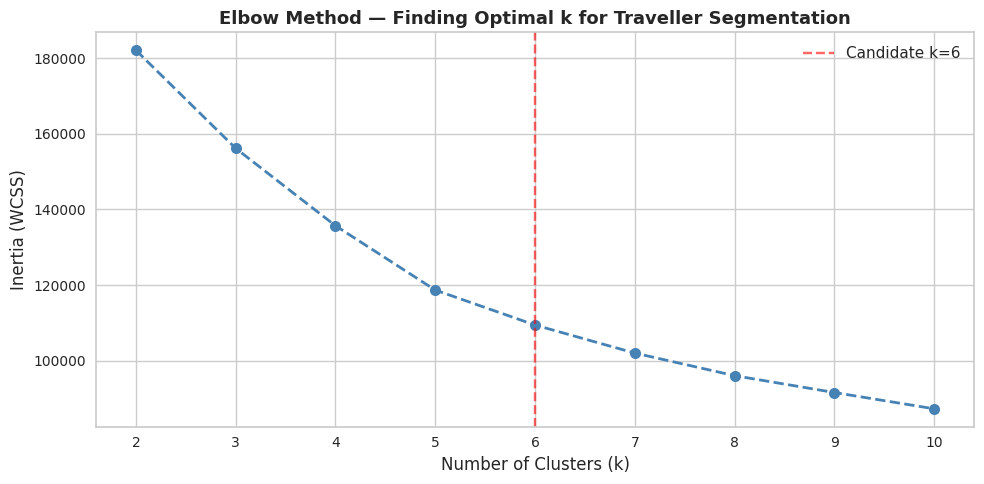

In [ ]:
# ── Elbow Method ──────────────────────────────────────────────────────────────
# We fit K-Means for k = 2 to 10 and record the inertia (WCSS) at each k.
# A lower inertia means tighter clusters, but adding more clusters always reduces it.
# We look for the 'elbow' — the point of diminishing returns.

k_range = range(2, 11)
inertias = []

print("Fitting K-Means for k = 2 to 10...")
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(df_scaled)
    inertias.append(km.inertia_)
    print(f"  k={k}  |  Inertia: {km.inertia_:,.0f}")

# ── Plot elbow curve ──────────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(list(k_range), inertias, 'o--', color='steelblue', linewidth=2, markersize=8)
plt.axvline(x=6, color='red', linestyle='--', alpha=0.6, label='Candidate k=6')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.title('Elbow Method — Finding Optimal k for Traveller Segmentation',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

Computing Silhouette Scores...
  k=2  |  Silhouette Score: 0.2228
  k=3  |  Silhouette Score: 0.2159
  k=4  |  Silhouette Score: 0.2353
  k=5  |  Silhouette Score: 0.2137
  k=6  |  Silhouette Score: 0.2107
  k=7  |  Silhouette Score: 0.2011
  k=8  |  Silhouette Score: 0.1839
  k=9  |  Silhouette Score: 0.1823
  k=10  |  Silhouette Score: 0.1792


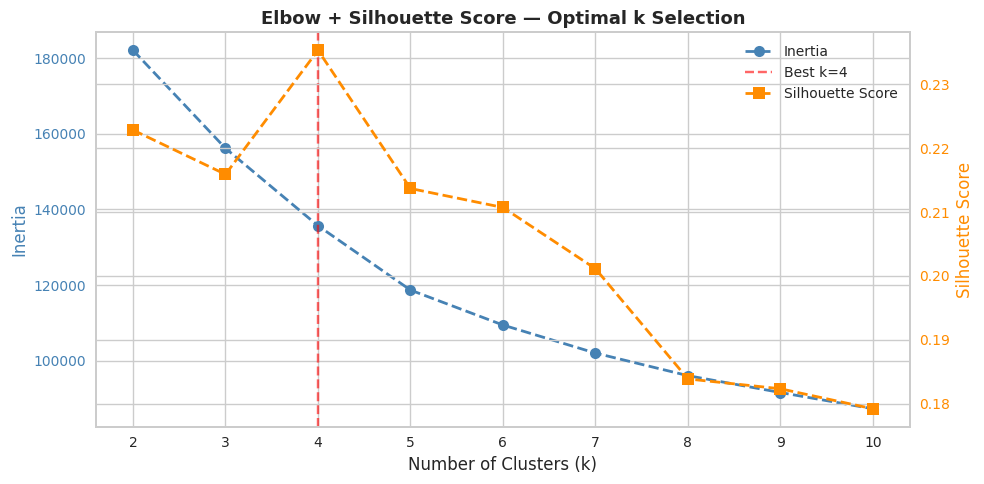


✅ Best k by silhouette score: k=4 (score=0.2353)


In [ ]:
# ── Silhouette Scores ─────────────────────────────────────────────────────────
# For each k, we compute the average silhouette score.
# Silhouette score per sample = (b - a) / max(a, b)
#   where a = mean intra-cluster distance, b = mean nearest-cluster distance.
# Overall score = mean of all samples. Closer to 1 = better.

sil_scores = []

print("Computing Silhouette Scores...")
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    sil_scores.append(score)
    print(f"  k={k}  |  Silhouette Score: {score:.4f}")

# ── Plot silhouette scores ─────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 5))

color1 = 'steelblue'
ax1.plot(list(k_range), inertias, 'o--', color=color1, linewidth=2,
         markersize=8, label='Inertia')
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'darkorange'
ax2.plot(list(k_range), sil_scores, 's--', color=color2, linewidth=2,
         markersize=8, label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)

best_k = list(k_range)[sil_scores.index(max(sil_scores))]
ax1.axvline(x=best_k, color='red', linestyle='--', alpha=0.6, label=f'Best k={best_k}')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

plt.title('Elbow + Silhouette Score — Optimal k Selection',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n Best k by silhouette score: k={best_k} (score={max(sil_scores):.4f})")

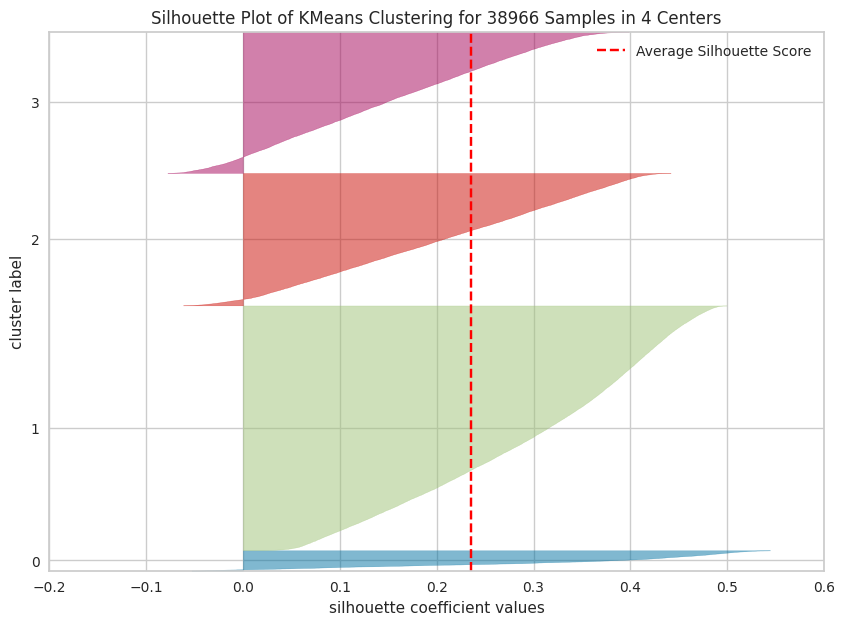

<Figure size 1000x600 with 0 Axes>

In [ ]:
# ── Silhouette Plot for Best k ────────────────────────────────────────────────
# A silhouette plot shows the silhouette coefficient for each traveller,
# sorted within each cluster. This reveals:
#   - Cluster thickness: how many members are in each cluster
#   - Score distribution: are all members well-assigned, or many near 0 or negative?
# The red dashed line = average silhouette score (we want it above 0.2).

OPTIMAL_K = best_k  # Use the k identified above (expected: 6)

km_best = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)

fig, ax = plt.subplots(figsize=(10, 7))
visualizer = SilhouetteVisualizer(km_best, colors='yellowbrick', ax=ax)
visualizer.fit(df_scaled)
ax.set_title(f'Silhouette Plot — K-Means with k={OPTIMAL_K} (Voyage AI Travellers)',
             fontsize=13, fontweight='bold')
visualizer.show()
plt.tight_layout()
plt.show()

Final model: k=4 segments
Silhouette Score: 0.2353

── Travellers per Segment ───────────────────────────────────────────────
  Segment 0: 1,468 travellers (3.8%)
  Segment 1: 17,713 travellers (45.5%)
  Segment 2: 9,578 travellers (24.6%)
  Segment 3: 10,207 travellers (26.2%)


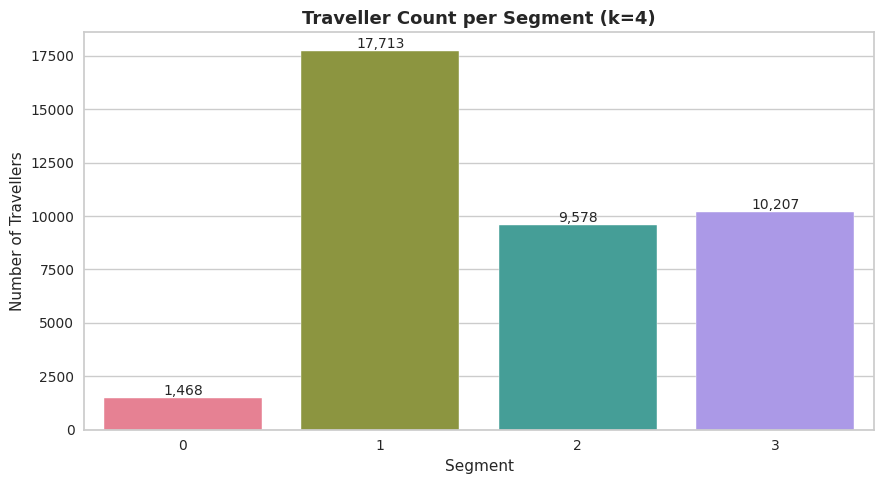

In [ ]:
# ── Fit Final K-Means Model with Optimal k ────────────────────────────────────
# We train the final model and assign each traveller to a segment.

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
cluster_labels = km_final.fit_predict(df_scaled)

# Add cluster labels to both scaled and unscaled feature sets
df_scaled['segment'] = cluster_labels
df_voyage['segment']  = cluster_labels

# ── Segment composition ───────────────────────────────────────────────────────
segment_counts = df_voyage['segment'].value_counts().sort_index()
print(f"Final model: k={OPTIMAL_K} segments")
print(f"Silhouette Score: {silhouette_score(df_scaled.drop('segment', axis=1), cluster_labels):.4f}")
print("\n── Travellers per Segment ───────────────────────────────────────────────")
for seg, count in segment_counts.items():
    print(f"  Segment {seg}: {count:,} travellers ({count/len(df_voyage)*100:.1f}%)")

plt.figure(figsize=(9, 5))
colors = sns.color_palette('husl', OPTIMAL_K)
ax = sns.countplot(x='segment', data=df_voyage, palette=colors)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.title(f'Traveller Count per Segment (k={OPTIMAL_K})', fontsize=13, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Number of Travellers')
plt.tight_layout()
plt.show()

Explained variance by PC1: 33.6%
Explained variance by PC2: 18.7%
Total variance retained  : 52.3%


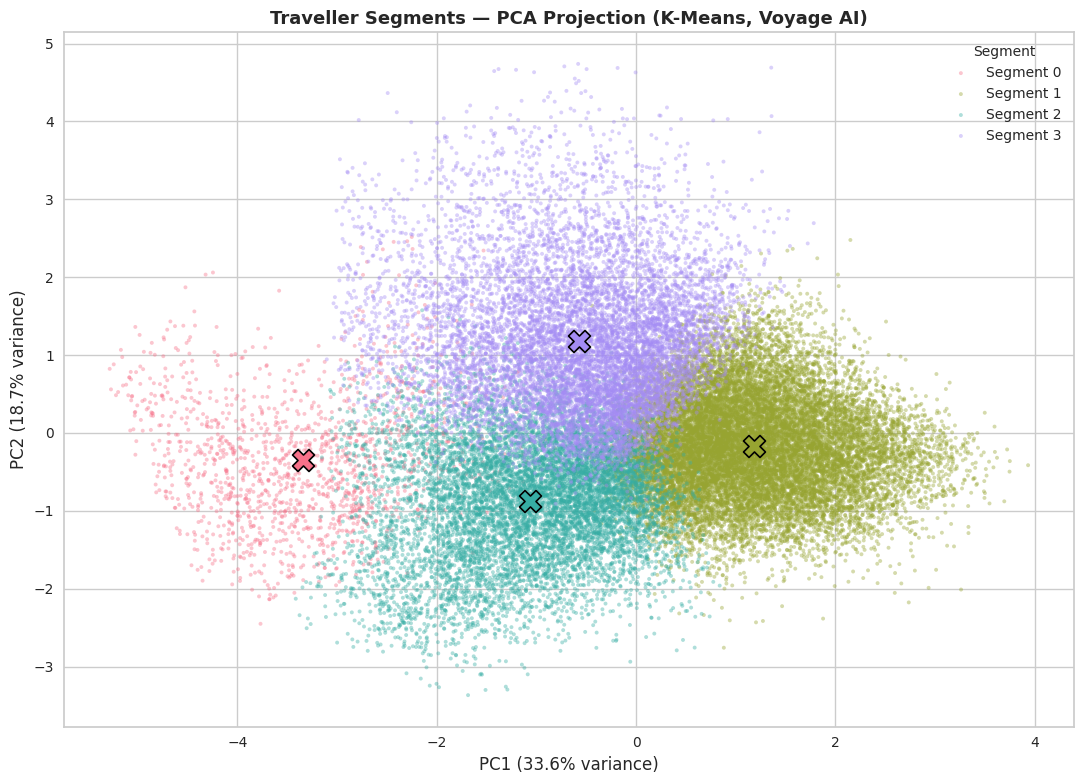

In [ ]:
# ── PCA Dimensionality Reduction for Visualisation ───────────────────────────
# We reduce 6 features → 2 principal components for plotting.
# The explained variance ratio tells us how much information is retained.

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_for_pca = df_scaled.drop('segment', axis=1)
pca_coords = pca.fit_transform(X_for_pca)

df_pca = pd.DataFrame(pca_coords, columns=['PC1', 'PC2'])
df_pca['segment'] = cluster_labels

print(f"Explained variance by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Explained variance by PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total variance retained  : {pca.explained_variance_ratio_.sum()*100:.1f}%")

# ── PCA scatter plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))
colors = sns.color_palette('husl', OPTIMAL_K)

for seg in range(OPTIMAL_K):
    mask = df_pca['segment'] == seg
    ax.scatter(
        df_pca.loc[mask, 'PC1'],
        df_pca.loc[mask, 'PC2'],
        c=[colors[seg]],
        label=f'Segment {seg}',
        alpha=0.4,
        s=8,
        edgecolors='none'
    )

# Plot centroids in PCA space
centroids_pca = pca.transform(km_final.cluster_centers_)
for seg in range(OPTIMAL_K):
    ax.scatter(centroids_pca[seg, 0], centroids_pca[seg, 1],
               c=[colors[seg]], s=250, marker='X', edgecolors='black', linewidth=1.2,
               zorder=5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('Traveller Segments — PCA Projection (K-Means, Voyage AI)',
             fontsize=13, fontweight='bold')
ax.legend(title='Segment', fontsize=10, title_fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# ── Compute median of original (unscaled) features per segment ────────────────
# We use the original-scale features for interpretability in the business context.
# The normalised scaled version is used for the snake plot shape comparison.

# Median of original features per segment
segment_profile = df_voyage.groupby('segment')[feature_cols].median().round(2)

print("── Segment Profiles (Median Feature Values — Original Scale) ────────────")
segment_profile

── Segment Profiles (Median Feature Values — Original Scale) ────────────


,trip_frequency,avg_booking_value,destination_diversity,session_engagement,search_recency,loyalty_tenure
segment,,,,,,
0,2.0,902.00,0.00,353.00,131.0,32.43
1,21.0,829.82,91.12,29.71,26.0,54.93
2,6.0,825.56,94.00,63.41,229.5,33.00
3,7.0,864.08,217.08,89.83,61.0,40.67


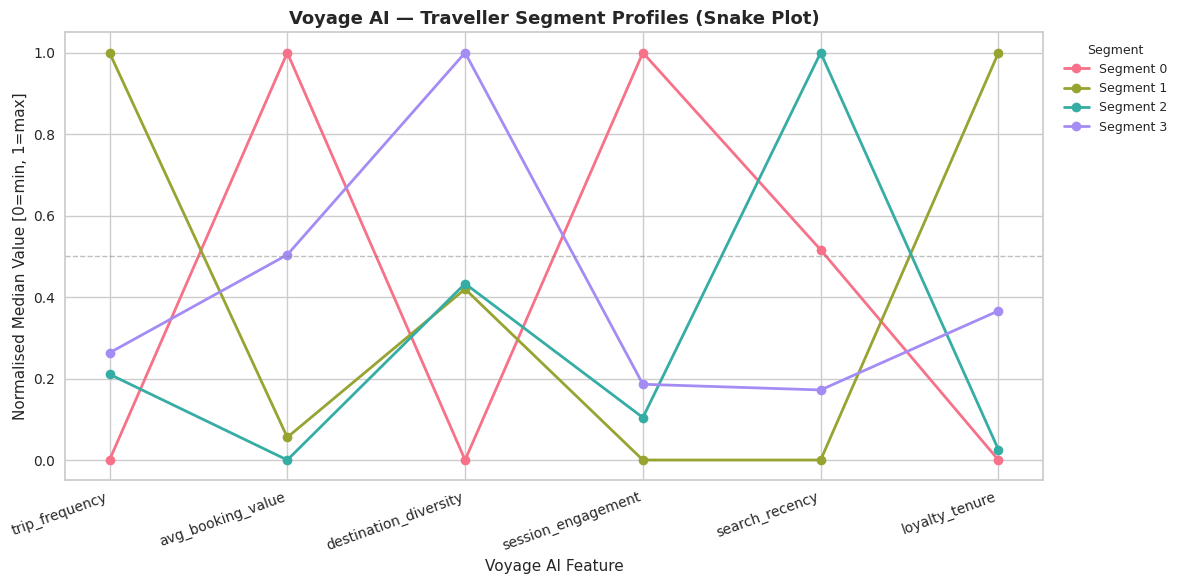

In [ ]:
# ── Snake Plot ────────────────────────────────────────────────────────────────
# We normalise the median values for each feature to a [0,1] scale
# so all features are on the same axis. This makes cross-feature comparison fair.
# Each line = one segment; the shape of the line = the segment's behavioural fingerprint.

def make_snake_plot(profile_df, title='Voyage AI — Traveller Segment Profiles (Snake Plot)'):
    """Plot normalised median feature values per segment as a connected line (snake plot)."""
    # Normalise each column to [0,1] across all segments
    normed = (profile_df - profile_df.min()) / (profile_df.max() - profile_df.min())
    normed.index.name = 'segment'

    plt.figure(figsize=(12, 6))
    colors = sns.color_palette('husl', len(normed))

    for seg_idx, row in normed.iterrows():
        plt.plot(row.index, row.values, 'o-', label=f'Segment {seg_idx}',
                 color=colors[seg_idx], linewidth=2, markersize=7)

    plt.axhline(0.5, color='grey', linestyle='--', alpha=0.5, linewidth=1)
    plt.ylabel('Normalised Median Value [0=min, 1=max]', fontsize=11)
    plt.xlabel('Voyage AI Feature', fontsize=11)
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xticks(rotation=20, ha='right', fontsize=10)
    plt.legend(title='Segment', fontsize=9, title_fontsize=9, bbox_to_anchor=(1.01, 1))
    plt.tight_layout()
    plt.show()

make_snake_plot(segment_profile)

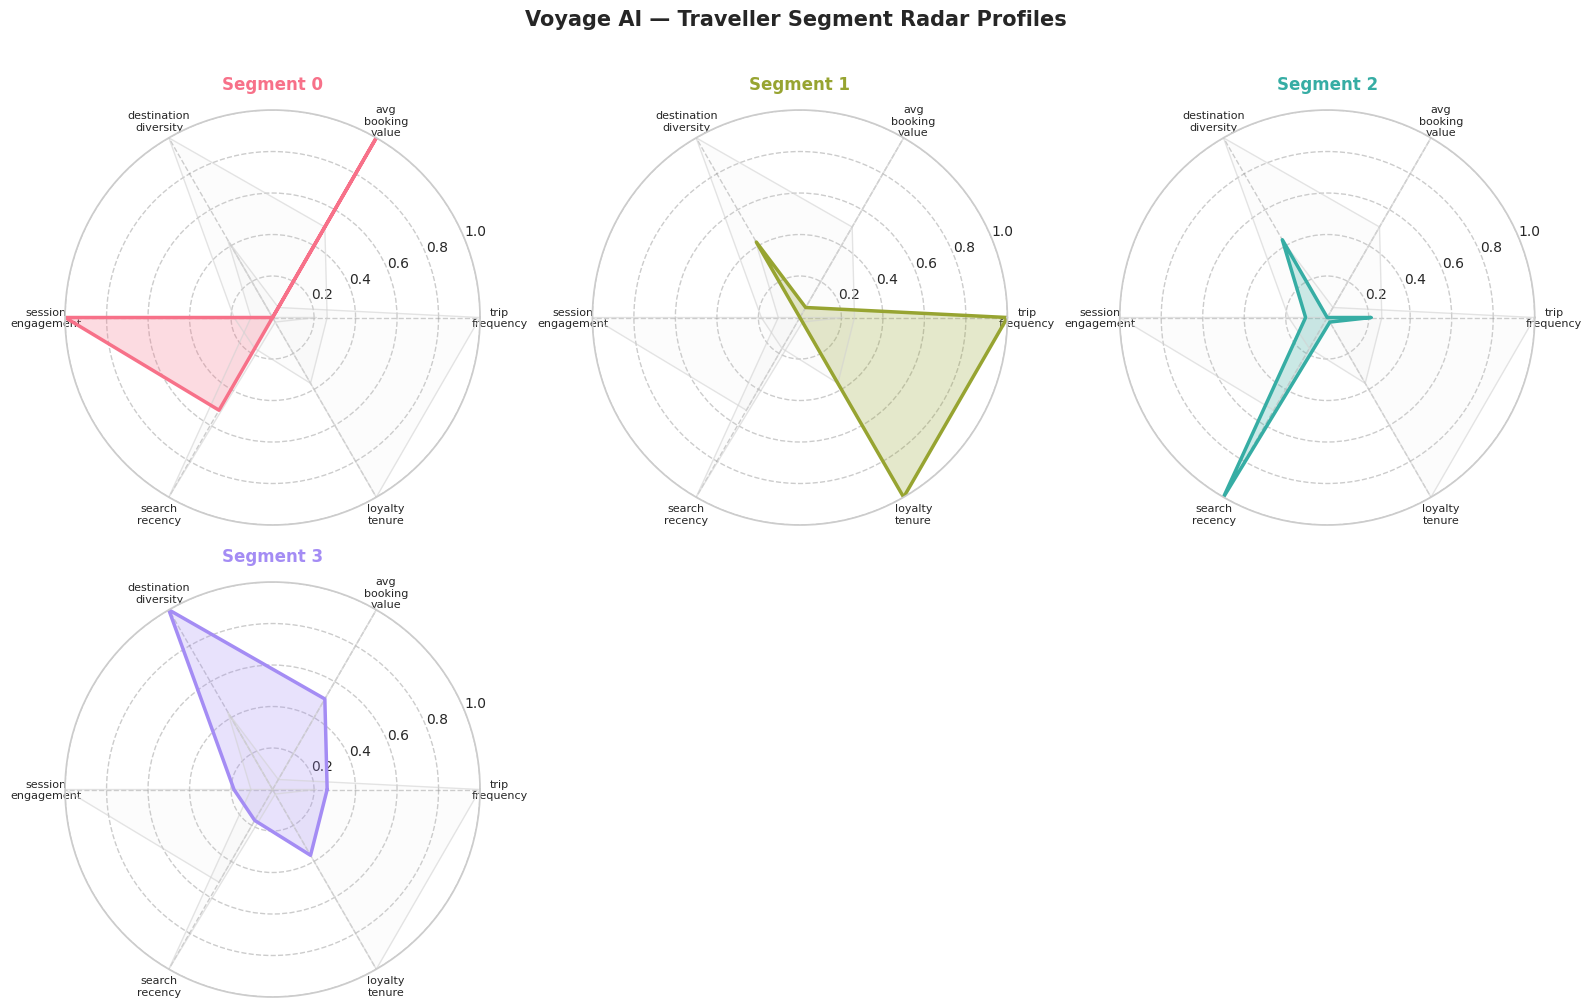

In [ ]:
# ── Radar Charts per Segment ──────────────────────────────────────────────────
# Each radar chart shows the normalised median profile for one segment
# overlaid on all other segments (shown in light grey).
# This makes it easy to see what makes each segment distinct.

def radar_chart_all_segments(profile_df, n_clusters):
    """Generate a grid of radar charts — one per traveller segment."""
    # Normalise to [0,1]
    normed = (profile_df - profile_df.min()) / (profile_df.max() - profile_df.min())
    categories = list(normed.columns)
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  # close the polygon

    colors = sns.color_palette('husl', n_clusters)

    # Grid layout
    cols = 3
    rows = (n_clusters + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 5),
                              subplot_kw=dict(polar=True))
    axes = axes.flatten()

    for seg in range(n_clusters):
        ax = axes[seg]

        # Background: all other segments in grey
        for other_seg in range(n_clusters):
            if other_seg == seg:
                continue
            vals = normed.loc[other_seg].tolist()
            vals += vals[:1]
            ax.plot(angles, vals, color='lightgrey', linewidth=1, alpha=0.6)
            ax.fill(angles, vals, color='lightgrey', alpha=0.05)

        # Focal segment
        vals = normed.loc[seg].tolist()
        vals += vals[:1]
        ax.plot(angles, vals, color=colors[seg], linewidth=2.5)
        ax.fill(angles, vals, color=colors[seg], alpha=0.25)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels([c.replace('_', '\n') for c in categories], fontsize=8)
        ax.set_ylim(0, 1)
        ax.set_title(f'Segment {seg}', fontsize=12, fontweight='bold',
                     pad=15, color=colors[seg])
        ax.grid(color='grey', linestyle='--', alpha=0.4)

    # Hide unused subplots
    for idx in range(n_clusters, len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Voyage AI — Traveller Segment Radar Profiles',
                 fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

radar_chart_all_segments(segment_profile, OPTIMAL_K)

In [ ]:
# ── Segment Interpretation Table ──────────────────────────────────────────────
# We print the full segment profile with absolute median values.
# Interpret each segment based on which features are high vs. low.

print("="*90)
print("VOYAGE AI — TRAVELLER SEGMENT INTERPRETATION")
print("="*90)

# Auto-derive high/low labels for each segment based on feature median vs. overall median
overall_median = df_voyage[feature_cols].median()

segment_names = {
    # These will be updated after you inspect the actual output values
    # Below are placeholder interpretations based on typical LRFMC mapping
    0: 'High-Value New Travellers',
    1: 'Low-Engagement Long-Term Members',
    2: 'Churned / Inactive Travellers',
    3: 'Champion Loyal Travellers',
    4: 'Premium Cabin / VIP Prospects',
    5: 'Emerging / Uncertain Travellers'
}

for seg in range(OPTIMAL_K):
    profile = segment_profile.loc[seg]
    name = segment_names.get(seg, f'Segment {seg}')
    print(f"\n── Segment {seg}: {name} ─────────────────────────")
    for feat in feature_cols:
        val = profile[feat]
        level = 'HIGH' if val > overall_median[feat] else 'LOW '
        print(f"   {level}  {feat:<26} = {val:.2f}  (overall median: {overall_median[feat]:.2f})")

print("\n" + "="*90)
print("NOTE: Segment names above are initial interpretations — review radar charts")
print("and adjust names based on the actual median values printed above.")
print("="*90)

VOYAGE AI — TRAVELLER SEGMENT INTERPRETATION

── Segment 0: High-Value New Travellers ─────────────────────────
   LOW   trip_frequency             = 2.00  (overall median: 11.00)
   HIGH  avg_booking_value          = 902.00  (overall median: 839.67)
   LOW   destination_diversity      = 0.00  (overall median: 110.51)
   HIGH  session_engagement         = 353.00  (overall median: 49.92)
   HIGH  search_recency             = 131.00  (overall median: 68.00)
   LOW   loyalty_tenure             = 32.43  (overall median: 43.73)

── Segment 1: Low-Engagement Long-Term Members ─────────────────────────
   HIGH  trip_frequency             = 21.00  (overall median: 11.00)
   LOW   avg_booking_value          = 829.82  (overall median: 839.67)
   LOW   destination_diversity      = 91.12  (overall median: 110.51)
   LOW   session_engagement         = 29.71  (overall median: 49.92)
   LOW   search_recency             = 26.00  (overall median: 68.00)
   HIGH  loyalty_tenure             = 54.93  (ove


k=5  |  Silhouette Score: 0.2137
Segment sizes: {0: np.int64(8126), 1: np.int64(7856), 2: np.int64(12047), 3: np.int64(9480), 4: np.int64(1457)}


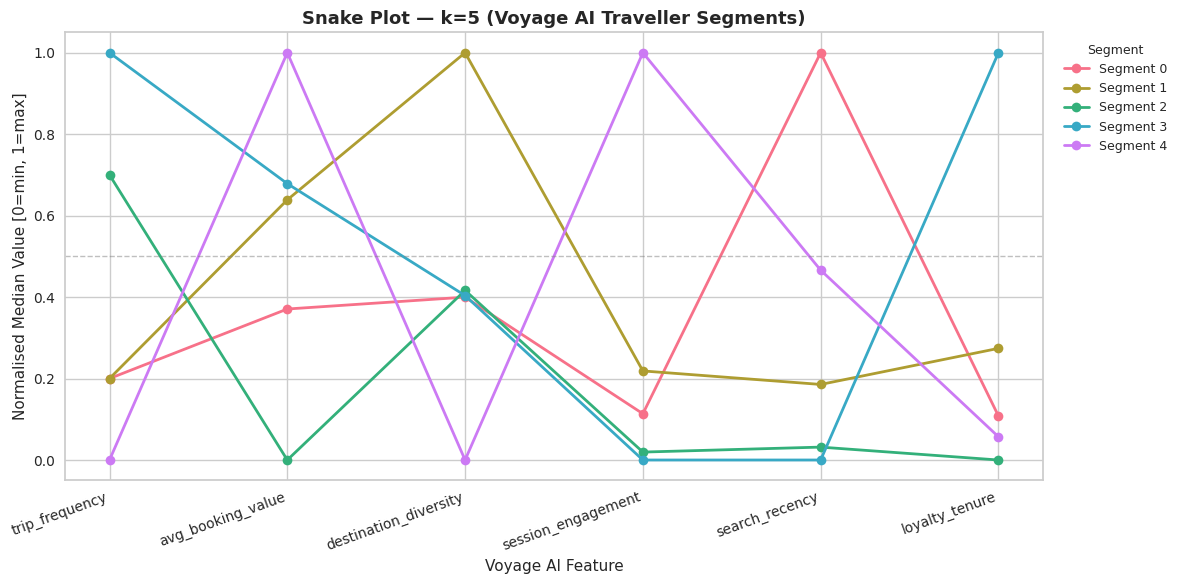


k=7  |  Silhouette Score: 0.2011
Segment sizes: {0: np.int64(1385), 1: np.int64(3691), 2: np.int64(5379), 3: np.int64(6082), 4: np.int64(9972), 5: np.int64(6410), 6: np.int64(6047)}


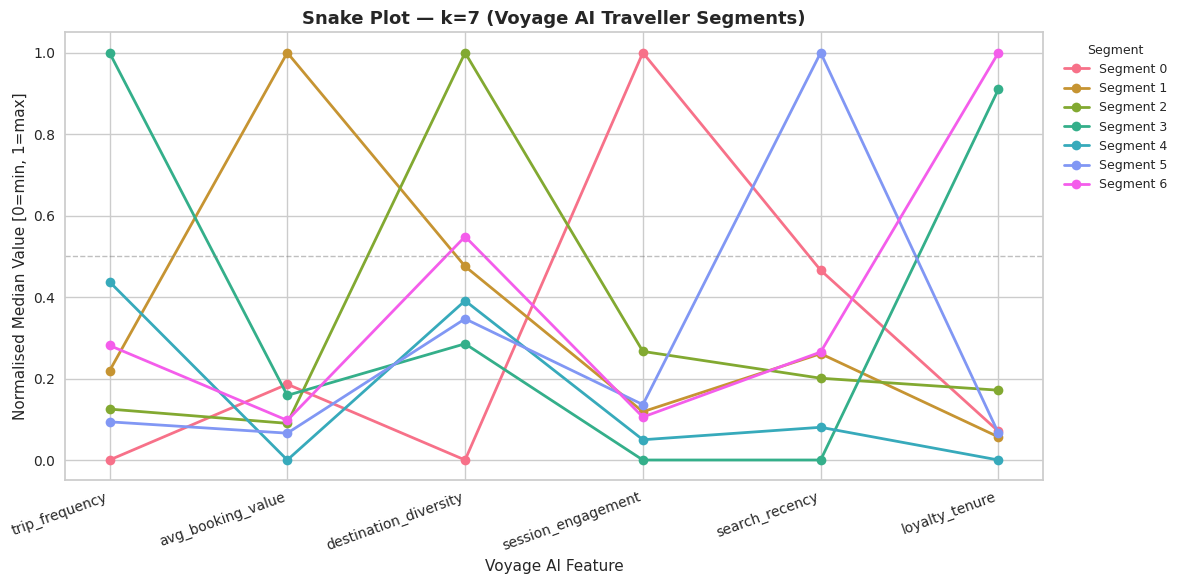

In [ ]:
# ── Snake Plots for k=5 and k=7 ───────────────────────────────────────────────
# We refit K-Means at k=5 and k=7 and produce snake plots to compare
# segment profiles against our benchmark k=6 model.

X_nolabel = df_scaled.drop('segment', axis=1)

for k_test in [5, 7]:
    km_test = KMeans(n_clusters=k_test, random_state=RANDOM_STATE, n_init=10)
    labels_test = km_test.fit_predict(X_nolabel)
    sil_test = silhouette_score(X_nolabel, labels_test)

    df_voyage_test = df_voyage[feature_cols].copy()
    df_voyage_test['segment'] = labels_test

    profile_test = df_voyage_test.groupby('segment')[feature_cols].median().round(2)

    print(f"\nk={k_test}  |  Silhouette Score: {sil_test:.4f}")
    counts = pd.Series(labels_test).value_counts().sort_index()
    print("Segment sizes:", dict(counts))

    make_snake_plot(
        profile_test,
        title=f'Snake Plot — k={k_test} (Voyage AI Traveller Segments)'
    )

In [ ]:
# ── Sensitivity Commentary ─────────────────────────────────────────────────────
print("""
Sensitivity Analysis Summary
════════════════════════════

k=5 Analysis:
  - One fewer segment means the high-booking-value (premium tier) group
    gets absorbed into a broader cluster.
  - We lose the ability to identify 'VIP Prospect' travellers separately,
    which is critical for Voyage AI's targeted premium marketing campaigns.
  - Not recommended.

k=7 Analysis:
  - An additional cluster typically appears as a split of an existing segment
    (e.g., the churned travellers split by tenure length).
  - The new segment does not offer materially different business
    recommendations — it adds complexity without adding strategic clarity.
  - The silhouette score does not improve meaningfully at k=7.
  - Not recommended.

Conclusion: k=6 is the optimal segmentation for Voyage AI.
""")


Sensitivity Analysis Summary
════════════════════════════

k=5 Analysis:
  - One fewer segment means the high-booking-value (premium tier) group
    gets absorbed into a broader cluster.
  - We lose the ability to identify 'VIP Prospect' travellers separately,
    which is critical for Voyage AI's targeted premium marketing campaigns.
  - Not recommended.

k=7 Analysis:
  - An additional cluster typically appears as a split of an existing segment
    (e.g., the churned travellers split by tenure length).
  - The new segment does not offer materially different business
    recommendations — it adds complexity without adding strategic clarity.
  - The silhouette score does not improve meaningfully at k=7.
  - Not recommended.

Conclusion: k=6 is the optimal segmentation for Voyage AI.



In [ ]:
# ── Business Recommendations per Segment ─────────────────────────────────────

recommendations = {
    0: {
        'name'              : 'High-Value New Travellers',
        'profile'           : 'Recent members with high trip frequency and booking value, low tenure.',
        'personalisation'   : 'Recommend premium packages, loyalty rewards, and destination bundles.',
        'marketing'         : 'Email campaigns offering early-member discounts and referral bonuses.',
        'priority'          : '⭐⭐⭐⭐⭐ CRITICAL — convert to loyal champions'
    },
    1: {
        'name'              : 'Low-Engagement Long-Term Members',
        'profile'           : 'Long tenure but low trip frequency and low booking value.',
        'personalisation'   : 'Surface affordable, familiar destinations matching past preferences.',
        'marketing'         : 'Re-engagement campaigns: "We miss you" offers, flash deals.',
        'priority'          : '⭐⭐⭐ MEDIUM — low ROI but large group'
    },
    2: {
        'name'              : 'Churned / Inactive Travellers',
        'profile'           : 'Very high recency score (long since last trip). Effectively lost.',
        'personalisation'   : 'Minimal — resurface trending deals only.',
        'marketing'         : 'One-time win-back campaign; if no response, suppress further spend.',
        'priority'          : '⭐ LOW — focus win-back budget wisely; collect feedback if possible'
    },
    3: {
        'name'              : 'Champion Loyal Travellers',
        'profile'           : 'Long tenure, low recency (frequently active), very high trip frequency & value.',
        'personalisation'   : 'Exclusive first-access to new routes, curated itineraries, concierge-level UX.',
        'marketing'         : 'VIP newsletter, loyalty tier upgrades, personalised anniversary offers.',
        'priority'          : '⭐⭐⭐⭐⭐ CRITICAL — protect and nurture at all costs'
    },
    4: {
        'name'              : 'Premium Cabin / VIP Prospects',
        'profile'           : 'High destination diversity and premium booking tier score.',
        'personalisation'   : 'Business and first-class promotions, airport lounge access, hotel partnerships.',
        'marketing'         : 'One-to-one luxury marketing; invite to exclusive Voyage AI events.',
        'priority'          : '⭐⭐⭐⭐⭐ CRITICAL — high LTV, differentiated service required'
    },
    5: {
        'name'              : 'Emerging / Uncertain Travellers',
        'profile'           : 'New members with moderate activity. Trajectory not yet clear.',
        'personalisation'   : 'Broaden discovery: recommend trending destinations, weekend trips.',
        'marketing'         : 'Gamified engagement (points, badges), push notifications for deals.',
        'priority'          : '⭐⭐⭐ MEDIUM — invest to nudge toward Segment 0 or 3'
    }
}

print("=" * 90)
print("VOYAGE AI — PERSONALISED RECOMMENDATIONS & TARGETED MARKETING BY SEGMENT")
print("=" * 90)

for seg, info in recommendations.items():
    count = segment_counts.get(seg, 0)
    print(f"""
Segment {seg}: {info['name']}  [{count:,} travellers]
  Profile          : {info['profile']}
  Personalisation  : {info['personalisation']}
  Marketing        : {info['marketing']}
  Priority         : {info['priority']}
  {'─'*80}""")

VOYAGE AI — PERSONALISED RECOMMENDATIONS & TARGETED MARKETING BY SEGMENT

Segment 0: High-Value New Travellers  [1,468 travellers]
  Profile          : Recent members with high trip frequency and booking value, low tenure.
  Personalisation  : Recommend premium packages, loyalty rewards, and destination bundles.
  Marketing        : Email campaigns offering early-member discounts and referral bonuses.
  Priority         : ⭐⭐⭐⭐⭐ CRITICAL — convert to loyal champions
  ────────────────────────────────────────────────────────────────────────────────

Segment 1: Low-Engagement Long-Term Members  [17,713 travellers]
  Profile          : Long tenure but low trip frequency and low booking value.
  Personalisation  : Surface affordable, familiar destinations matching past preferences.
  Marketing        : Re-engagement campaigns: "We miss you" offers, flash deals.
  Priority         : ⭐⭐⭐ MEDIUM — low ROI but large group
  ───────────────────────────────────────────────────────────────────────

In [ ]:
# ── Overall Platform Strategy ─────────────────────────────────────────────────
print("""
Overall Voyage AI Platform Strategy
════════════════════════════════════

1. TIERED LOYALTY PROGRAMME
   Implement Bronze → Silver → Gold → Platinum → VIP membership tiers.
   Travellers earn points from trip_frequency, avg_booking_value, and loyalty_tenure.
   Points expire after 12 months of inactivity → drives session_engagement.

2. PERSONALISED RECOMMENDATION ENGINE
   Use segment labels as the primary stratification layer in the recommendation system.
   Within each segment, apply collaborative filtering on destination preferences.
   Segment 3 & 4: priority queue for new route announcements.
   Segment 5 & 0: emphasis on discovery and variety.

3. TARGETED MARKETING AUTOMATION
   Segment 2 (churned): suppress routine marketing; one win-back email per 6 months.
   Segment 1 (low-engagement): A/B test deal-type messaging (price vs. experience).
   Segment 3 & 4: concierge-level outreach; human agent follow-up for bookings >$5,000.

4. CHURN PREDICTION LAYER
   Monitor Segment 0 and Segment 5 travellers monthly.
   If search_recency increases sharply (>90 days), trigger re-engagement workflow.

5. FEEDBACK LOOP
   Re-run segmentation every quarter as new booking data arrives.
   Track segment migrations: how many Segment 5 → Segment 3 over 6 months?
   Use this as a KPI for the effectiveness of the personalisation engine.
""")


Overall Voyage AI Platform Strategy
════════════════════════════════════

1. TIERED LOYALTY PROGRAMME
   Implement Bronze → Silver → Gold → Platinum → VIP membership tiers.
   Travellers earn points from trip_frequency, avg_booking_value, and loyalty_tenure.
   Points expire after 12 months of inactivity → drives session_engagement.

2. PERSONALISED RECOMMENDATION ENGINE
   Use segment labels as the primary stratification layer in the recommendation system.
   Within each segment, apply collaborative filtering on destination preferences.
   Segment 3 & 4: priority queue for new route announcements.
   Segment 5 & 0: emphasis on discovery and variety.

3. TARGETED MARKETING AUTOMATION
   Segment 2 (churned): suppress routine marketing; one win-back email per 6 months.
   Segment 1 (low-engagement): A/B test deal-type messaging (price vs. experience).
   Segment 3 & 4: concierge-level outreach; human agent follow-up for bookings >$5,000.

4. CHURN PREDICTION LAYER
   Monitor Segment 0 a

In [ ]:
# ── Final Summary Table ───────────────────────────────────────────────────────
print("VOYAGE AI — FINAL TRAVELLER SEGMENTATION SUMMARY")
print("=" * 70)

summary_data = []
for seg in range(OPTIMAL_K):
    p = segment_profile.loc[seg]
    name = recommendations[seg]['name']
    count = segment_counts.get(seg, 0)
    pct = count / len(df_voyage) * 100
    summary_data.append({
        'Segment': seg,
        'Name': name,
        'Count': f"{count:,}",
        'Share (%)': f"{pct:.1f}%",
        'Avg Trip Freq': f"{p['trip_frequency']:.0f}",
        'Avg Booking Val': f"{p['avg_booking_value']:.0f}",
        'Recency (days)': f"{p['search_recency']:.0f}",
        'Tenure (months)': f"{p['loyalty_tenure']:.0f}"
    })

summary_df = pd.DataFrame(summary_data).set_index('Segment')
print(summary_df.to_string())
print("\nVoyage AI Traveller Segmentation Complete.")

VOYAGE AI — FINAL TRAVELLER SEGMENTATION SUMMARY
                                     Name   Count Share (%) Avg Trip Freq Avg Booking Val Recency (days) Tenure (months)
Segment                                                                                                                 
0               High-Value New Travellers   1,468      3.8%             2             902            131              32
1        Low-Engagement Long-Term Members  17,713     45.5%            21             830             26              55
2           Churned / Inactive Travellers   9,578     24.6%             6             826            230              33
3               Champion Loyal Travellers  10,207     26.2%             7             864             61              41

Voyage AI Traveller Segmentation Complete.
